# Análise Consolidada - ENEM 2020 a 2023

Neste notebook iremos comparar as quatro edições lado a lado e responder à segunda pergunta da pesquisa:
1. Quais fatores socioeconômicos mais impactam o desempenho dos candidatos no ENEM?
2. **Essa relação se manteve estável entre as edições de 2020 a 2023?**

Como métrica de desempenho usaremos a **média geral** (média simples das notas das 4 provas objetivas e da redação).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ANOS = [2020, 2021, 2022, 2023]

PROCESSED_DIR = Path('..') / 'data' / 'processed'
FIGURES_ROOT = Path('..') / 'reports' / 'figures'
FIGURES_PATH = FIGURES_ROOT / 'consolidado'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

NOTAS = ['Nota_Ciencias_Natureza', 'Nota_Ciencias_Humanas', 'Nota_Linguagens',
         'Nota_Matematica', 'Nota_Redacao']
NOMES_NOTAS = {
    'Nota_Ciencias_Natureza': 'Ciências da Natureza',
    'Nota_Ciencias_Humanas': 'Ciências Humanas',
    'Nota_Linguagens': 'Linguagens e Códigos',
    'Nota_Matematica': 'Matemática',
    'Nota_Redacao': 'Redação',
    'Nota_Media_Geral': 'Média Geral',
}
PALETA_NOTAS = dict(zip(NOTAS, sns.color_palette('viridis', 5)))
COR_UNICA = '#31688e' # azul para séries únicas
COR_MEDIA_GERAL = '#333333'

MAPA_DEP_ADM = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
ORDEM_REDES = ['Federal', 'Privada', 'Estadual', 'Municipal']
PALETA_REDES = dict(zip(ORDEM_REDES, sns.color_palette('viridis', 5)[:4]))


def salvar(fig, nome):
    """Salva a figura em reports/figures/consolidado/."""
    caminho = FIGURES_PATH / f'{nome}.png'
    fig.savefig(caminho, dpi=300, bbox_inches='tight')
    print(f'Figura disponível em {caminho}')

## 1. Carregamento

Carregamos apenas as colunas usadas nas comparações (notas, tipo e rede da escola, sexo e as 10 questões do questionário socioeconômico) para manter as quatro edições juntas na memória. A coluna `Ano` já vem do tratamento.

Ao final, o consolidado é salvo em `data/processed/enem_2020_2023_consolidado.parquet`.

In [2]:
COLUNAS = NOTAS + ['Ano', 'Tipo_Escola', 'Dependencia_Adm_Escola', 'Sexo',
                   'Q1_Esc_Pai', 'Q2_Esc_Mae', 'Q3_Ocup_Pai', 'Q4_Ocup_Mae',
                   'Q5_Pessoas_Resid', 'Q6_Renda_Fam', 'Q8_Banheiro',
                   'Q12_Geladeira', 'Q24_Computador', 'Q25_Internet']

partes = []
for ano in ANOS:
    parte = pd.read_parquet(PROCESSED_DIR / f'enem_{ano}_tratado.parquet', columns=COLUNAS)
    print(f'{ano}: {len(parte):,} candidatos')
    partes.append(parte)

df_all = pd.concat(partes, ignore_index=True)
del partes

df_all['Q5_Pessoas_Resid'] = pd.to_numeric(df_all['Q5_Pessoas_Resid'], errors='coerce').astype('float32')
for col in df_all.select_dtypes(include='object').columns:
    df_all[col] = df_all[col].astype('category')
for col in NOTAS:
    df_all[col] = df_all[col].astype('float32')

df_all['Nota_Media_Geral'] = df_all[NOTAS].mean(axis=1).astype('float32')
df_all['Dependencia_Adm_Label'] = df_all['Dependencia_Adm_Escola'].map(MAPA_DEP_ADM).astype('category')

print(f'\ndf_all: {len(df_all):,} linhas x {df_all.shape[1]} colunas')
print(f'Memória: {df_all.memory_usage(deep=True).sum() / 1e9:.2f} GB')

2020: 2,242,169 candidatos
2021: 1,870,734 candidatos
2022: 1,927,753 candidatos
2023: 2,166,843 candidatos


C:\Users\Mauro\AppData\Local\Temp\ipykernel_63004\3054945352.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_all.select_dtypes(include='object').columns:



df_all: 8,207,499 linhas x 21 colunas
Memória: 0.37 GB


In [3]:
CONSOLIDADO_PATH = PROCESSED_DIR / 'enem_2020_2023_consolidado.parquet'
df_all.to_parquet(CONSOLIDADO_PATH)
print(f'Parquet consolidado salvo: {CONSOLIDADO_PATH} '
      f'({CONSOLIDADO_PATH.stat().st_size / 1e6:.0f} MB)')

Parquet consolidado salvo: ..\data\processed\enem_2020_2023_consolidado.parquet (116 MB)


## 2. Evolução das médias

Uma linha por prova + a média geral destacada. A célula também imprime o quanto 2020 (edição aplicada em plena pandemia, com abstenção recorde) desvia da média de 2021–2023 - qualquer desvio deve ser lido com cautela, pois o perfil de quem compareceu à prova em 2020 mudou.

Figura disponível em ..\reports\figures\consolidado\fig_20_evolucao_media_notas.png


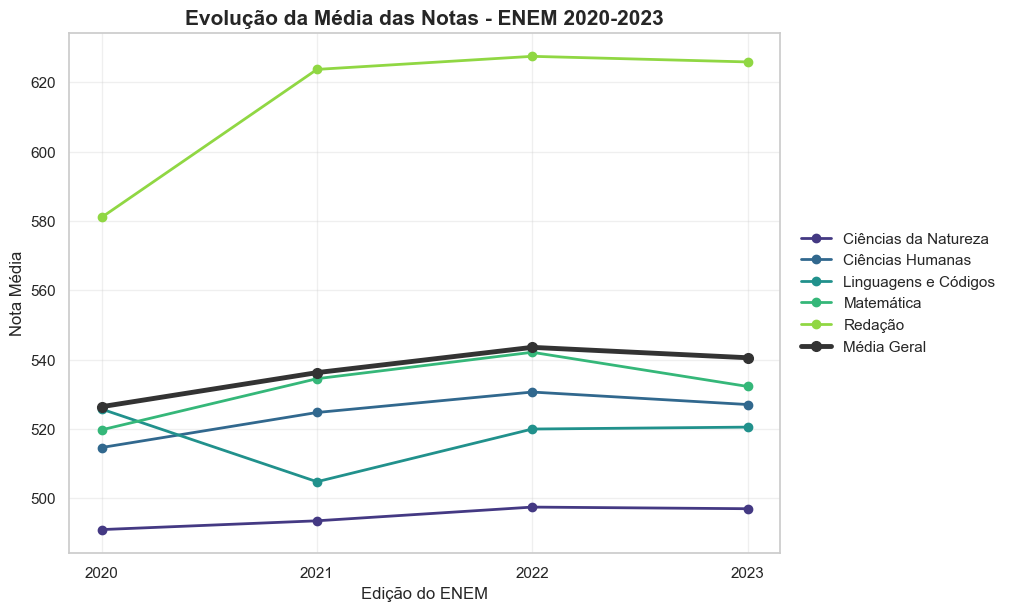

Média Geral 2020: 526.4 | Média de 2021-2023: 540.1 | Desvio de 2020: -13.7 pontos
Prova em que 2020 mais Destoa: Redação (-44.7 pontos vs média 2021-2023)


In [4]:
medias_ano = df_all.groupby('Ano')[NOTAS + ['Nota_Media_Geral']].mean()

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for nota in NOTAS:
    ax.plot(medias_ano.index, medias_ano[nota], marker='o', markersize=6,
            linewidth=2, color=PALETA_NOTAS[nota], label=NOMES_NOTAS[nota])
ax.plot(medias_ano.index, medias_ano['Nota_Media_Geral'], marker='o', markersize=7,
        linewidth=3.5, color=COR_MEDIA_GERAL, label='Média Geral')
ax.set_xticks(ANOS)
ax.set_xlabel('Edição do ENEM')
ax.set_ylabel('Nota Média')
ax.set_title('Evolução da Média das Notas - ENEM 2020-2023', fontsize=15, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
salvar(fig, 'fig_20_evolucao_media_notas')
plt.show()

# Análise se edição 2020 destoa das demais
ref_2123 = medias_ano.loc[[2021, 2022, 2023], 'Nota_Media_Geral'].mean()
delta_2020 = medias_ano.loc[2020, 'Nota_Media_Geral'] - ref_2123
print(f'Média Geral 2020: {medias_ano.loc[2020, "Nota_Media_Geral"]:.1f} | '
      f'Média de 2021-2023: {ref_2123:.1f} | Desvio de 2020: {delta_2020:+.1f} pontos')
desvios_2020 = medias_ano.loc[2020, NOTAS] - medias_ano.loc[[2021, 2022, 2023], NOTAS].mean()
prova_destoa = desvios_2020.abs().idxmax()
print(f'Prova em que 2020 mais Destoa: {NOMES_NOTAS[prova_destoa]} '
      f'({desvios_2020[prova_destoa]:+.1f} pontos vs média 2021-2023)')

## 3. Comparação de gap entre escola privada × pública

Gap = média da rede privada − média da rede pública, por prova e na média geral. A pergunta aqui é: o gap cresceu, diminuiu ou ficou estável entre 2020 e 2023?

Figura disponível em ..\reports\figures\consolidado\fig_21_gap_publica_privada.png


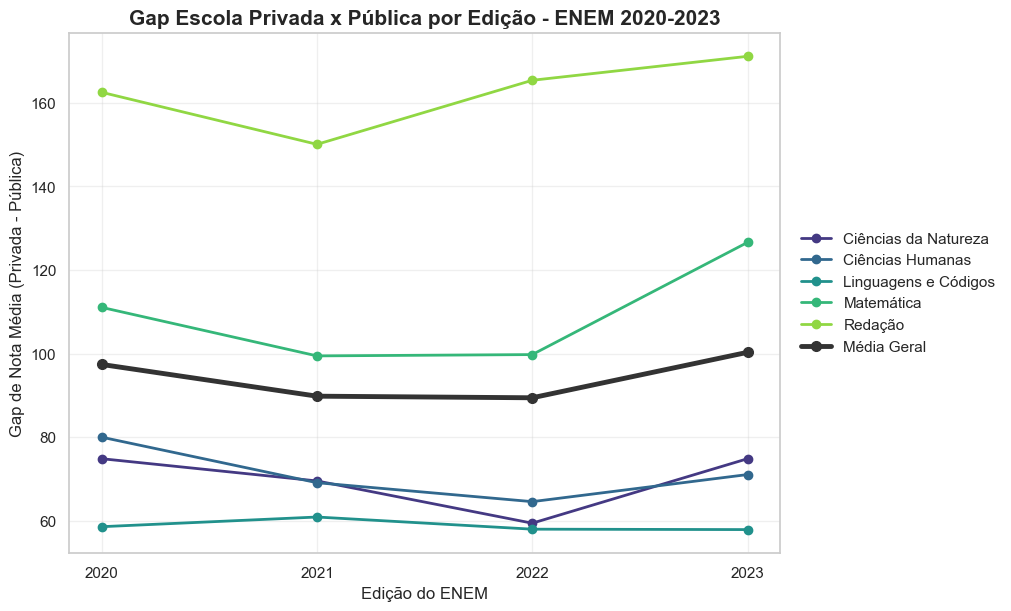

Gap na Média Feral: 2020 = 97.4 pontos | 2023 = 100.3 pontos (+2.9)


In [5]:
por_tipo_escola = (df_all[df_all['Tipo_Escola'].isin([2, 3])]
                   .groupby(['Ano', 'Tipo_Escola'], observed=True)[NOTAS + ['Nota_Media_Geral']]
                   .mean())
gap_escola = por_tipo_escola.xs(3, level='Tipo_Escola') - por_tipo_escola.xs(2, level='Tipo_Escola')

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for nota in NOTAS:
    ax.plot(gap_escola.index, gap_escola[nota], marker='o', markersize=6,
            linewidth=2, color=PALETA_NOTAS[nota], label=NOMES_NOTAS[nota])
ax.plot(gap_escola.index, gap_escola['Nota_Media_Geral'], marker='o', markersize=7,
        linewidth=3.5, color=COR_MEDIA_GERAL, label='Média Geral')
ax.set_xticks(ANOS)
ax.set_xlabel('Edição do ENEM')
ax.set_ylabel('Gap de Nota Média (Privada - Pública)')
ax.set_title('Gap Escola Privada x Pública por Edição - ENEM 2020-2023',
             fontsize=15, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
salvar(fig, 'fig_21_gap_publica_privada')
plt.show()

gap20 = gap_escola.loc[2020, 'Nota_Media_Geral']
gap23 = gap_escola.loc[2023, 'Nota_Media_Geral']
print(f'Gap na Média Feral: 2020 = {gap20:.1f} pontos | 2023 = {gap23:.1f} pontos ({gap23 - gap20:+.1f})')

## 4. Correlações de Spearman por edição

Um único heatmap **fatores × anos** com o ρ de cada fator com a média geral.

In [6]:
ESCALA = {letra: pos for pos, letra in enumerate('ABCDEFGHIJKLMNOPQ')}


def codificar_ordinal(serie, validas):
    """Letra -> posição ordinal; valores fora de `validas` (ex.: 'Não sei') viram NaN."""
    return serie.map({letra: ESCALA[letra] for letra in validas}).astype('float32')

# Mesma coisa dos notebooks de cada ano, mas aqui aplicamos uma única vez sobre o df_all inteiro
explicativas_all = pd.DataFrame({
    'Escolaridade do pai (Q1)': codificar_ordinal(df_all['Q1_Esc_Pai'], 'ABCDEFG'),
    'Escolaridade da mãe (Q2)': codificar_ordinal(df_all['Q2_Esc_Mae'], 'ABCDEFG'),
    'Ocupação do pai (Q3)': codificar_ordinal(df_all['Q3_Ocup_Pai'], 'ABCDE'),
    'Ocupação da mãe (Q4)': codificar_ordinal(df_all['Q4_Ocup_Mae'], 'ABCDE'),
    'Pessoas na residência (Q5)': df_all['Q5_Pessoas_Resid'],
    'Renda familiar (Q6)': codificar_ordinal(df_all['Q6_Renda_Fam'], 'ABCDEFGHIJKLMNOPQ'),
    'Nº de banheiros (Q8)': codificar_ordinal(df_all['Q8_Banheiro'], 'ABCDE'),
    'Nº de geladeiras (Q12)': codificar_ordinal(df_all['Q12_Geladeira'], 'ABCDE'),
    'Nº de computadores (Q24)': codificar_ordinal(df_all['Q24_Computador'], 'ABCDE'),
    'Tem internet (Q25)': codificar_ordinal(df_all['Q25_Internet'], 'AB'),
    'Tipo de escola (Pública=0, Privada=1)': df_all['Tipo_Escola'].map({2: 0, 3: 1}).astype('float32'),
    'Sexo (M=0, F=1)': df_all['Sexo'].map({'M': 0, 'F': 1}).astype('float32'),
})

correlacoes_ano = pd.DataFrame({
    ano: explicativas_all[df_all['Ano'] == ano].corrwith(
        df_all.loc[df_all['Ano'] == ano, 'Nota_Media_Geral'], method='spearman')
    for ano in ANOS
})

# Fatores ordenados pelo |ρ| médio dos 4 anos
correlacoes_ano = correlacoes_ano.loc[
    correlacoes_ano.abs().mean(axis=1).sort_values(ascending=False).index]
correlacoes_ano.round(3)

,2020,2021,2022,2023
Renda familiar (Q6),0.461,0.465,0.467,0.459
Nº de computadores (Q24),0.426,0.450,0.435,0.421
"Tipo de escola (Pública=0, Privada=1)",0.405,0.401,0.407,0.425
Ocupação do pai (Q3),0.395,0.387,0.391,0.389
Escolaridade do pai (Q1),0.385,0.370,0.376,0.376
Ocupação da mãe (Q4),0.379,0.367,0.374,0.375
Escolaridade da mãe (Q2),0.376,0.356,0.368,0.372
Nº de banheiros (Q8),0.349,0.345,0.338,0.337
Tem internet (Q25),0.245,0.208,0.198,0.187
Nº de geladeiras (Q12),0.134,0.130,0.123,0.129


Figura disponível em ..\reports\figures\consolidado\fig_22_correlacoes_por_ano.png


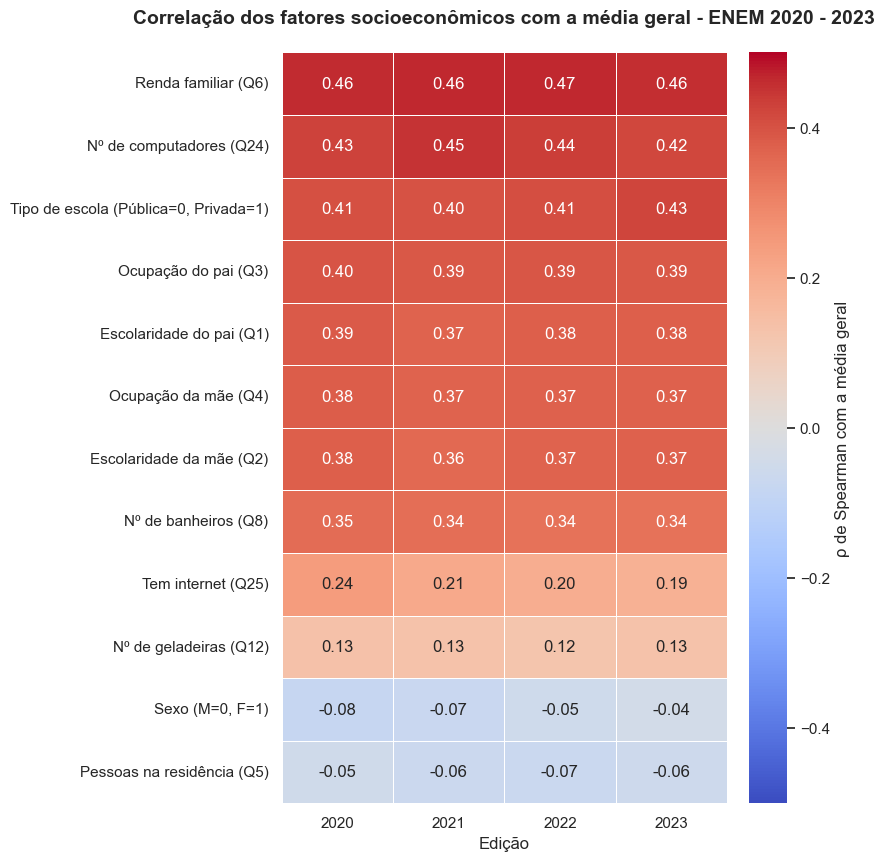

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 8.5), constrained_layout=True)
sns.heatmap(correlacoes_ano, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'ρ de Spearman com a média geral'}, ax=ax)
ax.set_title('Correlação dos fatores socioeconômicos com a média geral - ENEM 2020 - 2023\n', fontsize=14, fontweight='bold')
ax.set_xlabel('Edição')
salvar(fig, 'fig_22_correlacoes_por_ano')
plt.show()

## 5. Correlação da dependência administrativa da escola com o desempenho

A rede (federal, estadual, municipal, privada) ficou fora da matriz de Spearman dos notebooks anuais por ser **nominal** - não existe ordem natural entre as categorias. Para medir a associação entre uma variável nominal e uma nota contínua usaremos o **η² (eta ao quadrado)**: a razão entre a variação das médias dos grupos e a variação total das notas (SQ_entre / SQ_total). Ele responde: *que fração da variação da média geral é explicada só por saber a rede da escola do candidato?*

Como régua de comparação, calculamos o mesmo η² para as faixas de renda no **mesmo recorte** de candidatos - apenas quem tem escola identificada (o INEP só informa a escola dos concluintes do ensino médio, então esta seção usa esse subconjunto).

Em seguida, duas perguntas específicas serão respondidas:
- **A federal "fura a bolha"?** - a distribuição das federais alcança a das privadas? (medianas por rede, % de alunos de federais acima da mediana das privadas e a comparação dentro de cada faixa de renda, para afastar o efeito "alunos de federal são mais ricos");
- **É fator definidor?** - onde fica o quarto mais fraco (P25) das federais em relação às medianas das outras redes? Se até ele supera as demais, a rede é quase definidora; se há sobreposição grande, não é.

In [8]:
def eta_squared(notas, grupos):
    """η² = SQ_entre / SQ_total: proporção da variação das notas explicada pelo grupo."""
    dados = pd.DataFrame({'nota': notas, 'grupo': grupos}).dropna()
    media_total = dados['nota'].mean()
    ss_total = ((dados['nota'] - media_total) ** 2).sum()
    medias_grupo = dados.groupby('grupo', observed=True)['nota'].transform('mean')
    return float(((medias_grupo - media_total) ** 2).sum() / ss_total)


FAIXAS_RENDA = {}
for letra in 'AB':
    FAIXAS_RENDA[letra] = 'até 1 SM'
for letra in 'CDEFGH':
    FAIXAS_RENDA[letra] = '1 a 5 SM'
for letra in 'IJKLM':
    FAIXAS_RENDA[letra] = '5 a 10 SM'
for letra in 'NOPQ':
    FAIXAS_RENDA[letra] = 'mais de 10 SM'
ORDEM_FAIXAS = ['até 1 SM', '1 a 5 SM', '5 a 10 SM', 'mais de 10 SM']
df_all['Faixa_Renda'] = df_all['Q6_Renda_Fam'].map(FAIXAS_RENDA).astype('category')

linhas = []
for ano in ANOS:
    sub = df_all[(df_all['Ano'] == ano) & df_all['Dependencia_Adm_Label'].notna()]
    linhas.append({
        'Ano': ano,
        'η² rede administrativa': eta_squared(sub['Nota_Media_Geral'], sub['Dependencia_Adm_Label']),
        'η² faixa de renda (mesmo recorte)': eta_squared(sub['Nota_Media_Geral'], sub['Faixa_Renda']),
        'candidatos com escola identificada': len(sub),
    })
tabela_eta = pd.DataFrame(linhas).set_index('Ano').round(3)
print('Proporção da variação da média geral explicada por cada fator (η²),')
print('entre os candidatos com escola identificada:')
tabela_eta

Proporção da variação da média geral explicada por cada fator (η²),
entre os candidatos com escola identificada:


,η² rede administrativa,η² faixa de renda (mesmo recorte),candidatos com escola identificada
Ano,,,
2020,0.266,0.238,537909
2021,0.260,0.224,602451
2022,0.259,0.220,692915
2023,0.248,0.212,721429


### Medianas por rede, 2020–2023

Figura disponível em ..\reports\figures\consolidado\fig_23_mediana_media_geral_por_rede.png


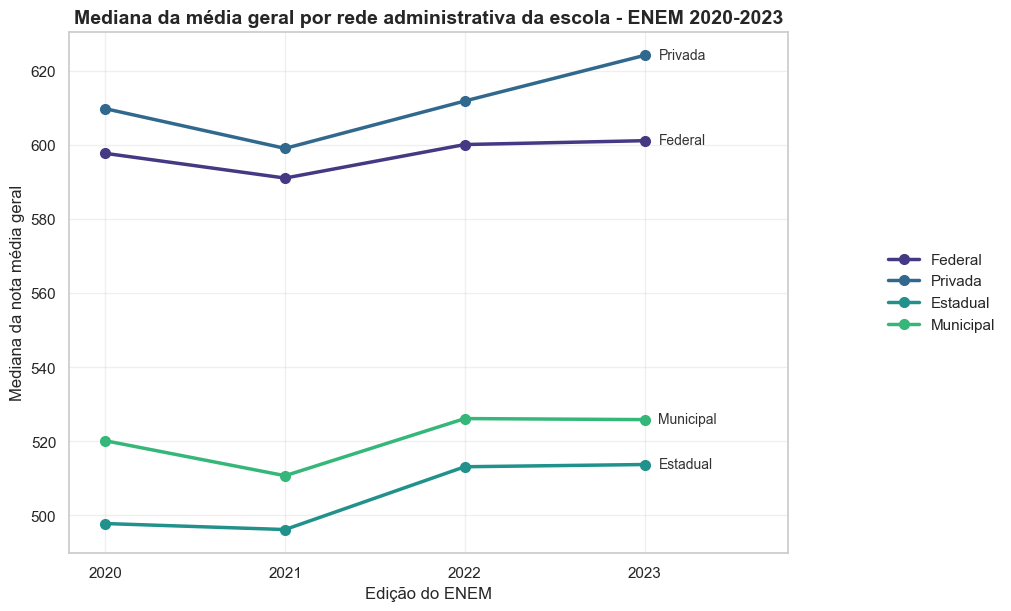

In [9]:
com_rede = df_all[df_all['Dependencia_Adm_Label'].notna()]
medianas_rede = (com_rede.groupby(['Ano', 'Dependencia_Adm_Label'], observed=True)['Nota_Media_Geral']
                 .median().unstack().reindex(columns=ORDEM_REDES))

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for rede in ORDEM_REDES:
    ax.plot(medianas_rede.index, medianas_rede[rede], marker='o', markersize=7,
            linewidth=2.5, color=PALETA_REDES[rede], label=rede)
    ax.annotate(rede, (ANOS[-1], medianas_rede.loc[ANOS[-1], rede]),
                textcoords='offset points', xytext=(10, 0), va='center',
                fontsize=10, color='#333333')
ax.set_xticks(ANOS)
ax.set_xlim(2019.8, 2023.8)
ax.set_xlabel('Edição do ENEM')
ax.set_ylabel('Mediana da nota média geral')
ax.set_title('Mediana da média geral por rede administrativa da escola - ENEM 2020-2023',
             fontsize=14, fontweight='bold')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.12, 0.5))
salvar(fig, 'fig_23_mediana_media_geral_por_rede')
plt.show()

In [10]:
print('A rede FEDERAL fura a bolha do gap pública x privada?\n')
linhas = []
for ano in ANOS:
    sub = com_rede[com_rede['Ano'] == ano]
    fed = sub.loc[sub['Dependencia_Adm_Label'] == 'Federal', 'Nota_Media_Geral']
    priv = sub.loc[sub['Dependencia_Adm_Label'] == 'Privada', 'Nota_Media_Geral']
    est = sub.loc[sub['Dependencia_Adm_Label'] == 'Estadual', 'Nota_Media_Geral']
    pct_acima_priv = (fed > priv.median()).mean() * 100
    linhas.append({'Ano': ano, 'Mediana Federal': fed.median(), 'Mediana Privada': priv.median(),
                   'Mediana Estadual': est.median(), 'P25 Federal': fed.quantile(0.25),
                   '% federais acima da mediana das privadas': pct_acima_priv,
                   'n Federal': len(fed)})
    print(f'{ano}: mediana Federal = {fed.median():.1f} vs Privada = {priv.median():.1f} '
          f'({fed.median() - priv.median():+.1f}); {pct_acima_priv:.0f}% dos alunos de federais '
          f'ficam acima da mediana das privadas (n federal = {len(fed):,})')
tabela_federal = pd.DataFrame(linhas).set_index('Ano').round(1)

print('\nEstudar em escola FEDERAL é definidor de bom desempenho?')
for ano in ANOS:
    linha = tabela_federal.loc[ano]
    acima_est = 'ACIMA' if linha['P25 Federal'] > linha['Mediana Estadual'] else 'abaixo'
    acima_priv = 'ACIMA' if linha['P25 Federal'] > linha['Mediana Privada'] else 'abaixo'
    print(f'{ano}: o quarto mais fraco das federais (P25 = {linha["P25 Federal"]:.1f}) fica '
          f'{acima_est} da mediana das estaduais ({linha["Mediana Estadual"]:.1f}) '
          f'e {acima_priv} da mediana das privadas ({linha["Mediana Privada"]:.1f})')
tabela_federal

A rede FEDERAL fura a bolha do gap pública x privada?

2020: mediana Federal = 597.8 vs Privada = 609.9 (-12.1); 44% dos alunos de federais ficam acima da mediana das privadas (n federal = 37,884)
2021: mediana Federal = 591.1 vs Privada = 599.1 (-8.0); 46% dos alunos de federais ficam acima da mediana das privadas (n federal = 41,021)
2022: mediana Federal = 600.2 vs Privada = 611.9 (-11.8); 43% dos alunos de federais ficam acima da mediana das privadas (n federal = 44,209)
2023: mediana Federal = 601.2 vs Privada = 624.3 (-23.0); 38% dos alunos de federais ficam acima da mediana das privadas (n federal = 43,946)

Estudar em escola FEDERAL é definidor de bom desempenho?
2020: o quarto mais fraco das federais (P25 = 537.8) fica ACIMA da mediana das estaduais (497.8) e abaixo da mediana das privadas (609.9)
2021: o quarto mais fraco das federais (P25 = 532.9) fica ACIMA da mediana das estaduais (496.2) e abaixo da mediana das privadas (599.1)
2022: o quarto mais fraco das federais (P25 

,Mediana Federal,Mediana Privada,Mediana Estadual,P25 Federal,% federais acima da mediana das privadas,n Federal
Ano,,,,,,
2020,597.799988,609.900024,497.799988,537.8,44.3,37884
2021,591.099976,599.099976,496.200012,532.9,46.0,41021
2022,600.200012,611.900024,513.200012,549.3,43.4,44209
2023,601.200012,624.299988,513.799988,545.0,38.2,43946


### Federal vs Privada dentro de cada faixa de renda

Se as federais só performam bem porque atraem alunos de renda mais alta, a vantagem deve sumir quando comparamos alunos da **mesma faixa de renda**. Gap positivo = privada na frente; negativo = federal na frente.

In [11]:
fed_priv = com_rede[com_rede['Dependencia_Adm_Label'].isin(['Federal', 'Privada'])]
medias_faixa = (fed_priv.groupby(['Ano', 'Faixa_Renda', 'Dependencia_Adm_Label'], observed=True)
                ['Nota_Media_Geral'].agg(['mean', 'count']).unstack())

gap_faixa = ((medias_faixa[('mean', 'Privada')] - medias_faixa[('mean', 'Federal')])
             .unstack('Faixa_Renda').reindex(columns=ORDEM_FAIXAS).astype('float64'))
n_federais = (medias_faixa[('count', 'Federal')].unstack('Faixa_Renda')
              .reindex(columns=ORDEM_FAIXAS).fillna(0).astype(int))

print('Gap de média geral (Privada - Federal) dentro de cada faixa de renda:')
print(gap_faixa.round(1).to_string())
print('\nNº de alunos de federais em cada célula (para checar o tamanho dos grupos):')
print(n_federais.to_string())

celulas_federal_frente = int((gap_faixa < 0).values.sum())
print(f'\nEm {celulas_federal_frente} de {gap_faixa.size} combinações ano x faixa de renda, '
      f'a média das federais SUPERA a das privadas.')

Gap de média geral (Privada - Federal) dentro de cada faixa de renda:
Faixa_Renda  até 1 SM  1 a 5 SM  5 a 10 SM  mais de 10 SM
Ano                                                      
2020              3.1      -9.3      -15.7          -10.2
2021             -0.4      -8.6      -18.8          -15.8
2022              2.7      -5.2      -14.3          -14.3
2023              6.2       1.7       -4.6           -8.5

Nº de alunos de federais em cada célula (para checar o tamanho dos grupos):
Faixa_Renda  até 1 SM  1 a 5 SM  5 a 10 SM  mais de 10 SM
Ano                                                      
2020             8748     22339       4623           1935
2021             8483     24664       5846           2028
2022            10199     26682       5393           1935
2023            11440     25817       5022           1667

Em 12 de 16 combinações ano x faixa de renda, a média das federais SUPERA a das privadas.


## 6. Análise consolidada 2020–2023

A célula abaixo reúne os números-chave calculados nas seções anteriores. A leitura desses números está na seção de conclusões, na sequência.

In [12]:
print('Números-chave da comparação 2020-2023:\n')

print('Top 5 fatores por |ρ| médio com a média geral nos 4 anos:')
abs_medio = correlacoes_ano.abs().mean(axis=1)
print(abs_medio.sort_values(ascending=False).head(5).round(2).to_string())

print('\nFator nº 1 de cada edição:')
print(correlacoes_ano.abs().idxmax().to_string())

print('\nGap privada - pública na média geral, por ano:')
print(gap_escola['Nota_Media_Geral'].astype(float).round(1).to_string())

print('\nη² da rede administrativa, por ano:')
print(tabela_eta['η² rede administrativa'].to_string())

print('\n% de alunos de federais acima da mediana das privadas, por ano:')
print(tabela_federal['% federais acima da mediana das privadas'].to_string())

print('\nMédia geral por edição (2020 destoa das demais?):')
print(medias_ano['Nota_Media_Geral'].astype(float).round(1).to_string())

Números-chave da comparação 2020-2023:

Top 5 fatores por |ρ| médio com a média geral nos 4 anos:
Renda familiar (Q6)                      0.46
Nº de computadores (Q24)                 0.43
Tipo de escola (Pública=0, Privada=1)    0.41
Ocupação do pai (Q3)                     0.39
Escolaridade do pai (Q1)                 0.38

Fator nº 1 de cada edição:
2020    Renda familiar (Q6)
2021    Renda familiar (Q6)
2022    Renda familiar (Q6)
2023    Renda familiar (Q6)

Gap privada - pública na média geral, por ano:
Ano
2020     97.4
2021     89.8
2022     89.4
2023    100.3

η² da rede administrativa, por ano:
Ano
2020    0.266
2021    0.260
2022    0.259
2023    0.248

% de alunos de federais acima da mediana das privadas, por ano:
Ano
2020    44.3
2021    46.0
2022    43.4
2023    38.2

Média geral por edição (2020 destoa das demais?):
Ano
2020    526.4
2021    536.2
2022    543.5
2023    540.5


### Conclusões

**1. O ranking de fatores é estável - e a renda familiar é o fator nº 1 em todas as edições.** A renda (Q006) lidera as quatro edições com ρ ≈ 0,46, seguida do nº de computadores em casa (ρ médio 0,43) e do tipo de escola (0,41). Os cinco primeiros colocados são os mesmos nos quatro anos, com variações de no máximo ~0,02 no ρ. A resposta à pergunta de pesquisa, portanto, não depende da edição escolhida: **fatores de capital econômico (renda e bens do domicílio) e o tipo de escola têm a maior relação com o desempenho, e essa hierarquia se manteve de 2020 a 2023**.

**2. A desigualdade não dá sinal de queda.** O gap privada−pública na média geral oscilou entre 89 e 100 pontos (97,4 em 2020; 89,8 em 2021; 89,4 em 2022; 100,3 em 2023, o maior da série) - magnitude equivalente a cerca de **um desvio-padrão** da média geral (≈ 89-97 pontos, conforme o ano), ou seja, uma diferença grande em termos práticos, não apenas estatísticos. Somada à estabilidade das correlações, a leitura é de desigualdade estável em patamar alto - não há tendência de melhora no período.

**3. A única tendência clara é a queda de "tem internet em casa".** O ρ caiu monotonicamente de 0,245 (2020) para 0,187 (2023). O resultado é coerente com a universalização do acesso à internet: quanto mais candidatos a têm, menos a variável separa grupos. Isso não significa que o acesso digital perdeu importância - o nº de computadores segue como 2º fator do ranking.

**4. A rede administrativa explica tanto quanto a renda - e a federal fura parcialmente a bolha.** Entre os candidatos com escola identificada, saber a rede explica 25-27% da variação da média geral (η²), um pouco acima da faixa de renda no mesmo recorte (21-24%). A mediana das federais fica de 8 a 23 pontos abaixo da das privadas, com 38-46% dos alunos de federais acima da mediana das privadas; porém, comparando alunos da **mesma faixa de renda**, as federais superam as privadas em 12 das 16 combinações ano × faixa. Ou seja, parte da vantagem da rede privada é composição de renda do alunado, não a escola em si. Estudar em federal, contudo, não é definidor: em todos os anos o quarto mais fraco das federais (P25) fica abaixo da mediana das privadas - ainda que acima da mediana das estaduais.

**5. 2020 destoa para baixo e pede cautela.** A média geral de 2020 (526,4) fica 13,7 pontos abaixo da média de 2021-2023, puxada sobretudo pela Redação (−44,7 pontos). Como a edição foi aplicada em plena pandemia, com abstenção recorde e não aleatória, diferenças de nível entre 2020 e os demais anos refletem também a mudança no perfil de quem compareceu. Por isso as conclusões acima se apoiam na estabilidade dos rankings e dos gaps, e não nos níveis absolutos das notas.

> **Limitações:**
> 
> (1) correlação e η² medem associação, não causa - renda, escolaridade dos pais, bens do domicílio e rede da escola andam juntos, e separar o efeito de cada um exigiria um modelo multivariado, fora do escopo deste trabalho;
> 
> (2) escolas federais selecionam alunos por prova de admissão - mesmo a comparação por faixa de renda não elimina esse viés de seleção;
> 
> (3) a rede administrativa só é conhecida para os concluintes do ensino médio;
> 
> (4) o perfil dos participantes muda entre edições (abstenção recorde em 2020), o que limita leituras finas de tendência.